In [1]:
from main import *
from environments import *
from agents import *
from simulator import *
import numpy as np
import matplotlib.pyplot as plt
import math

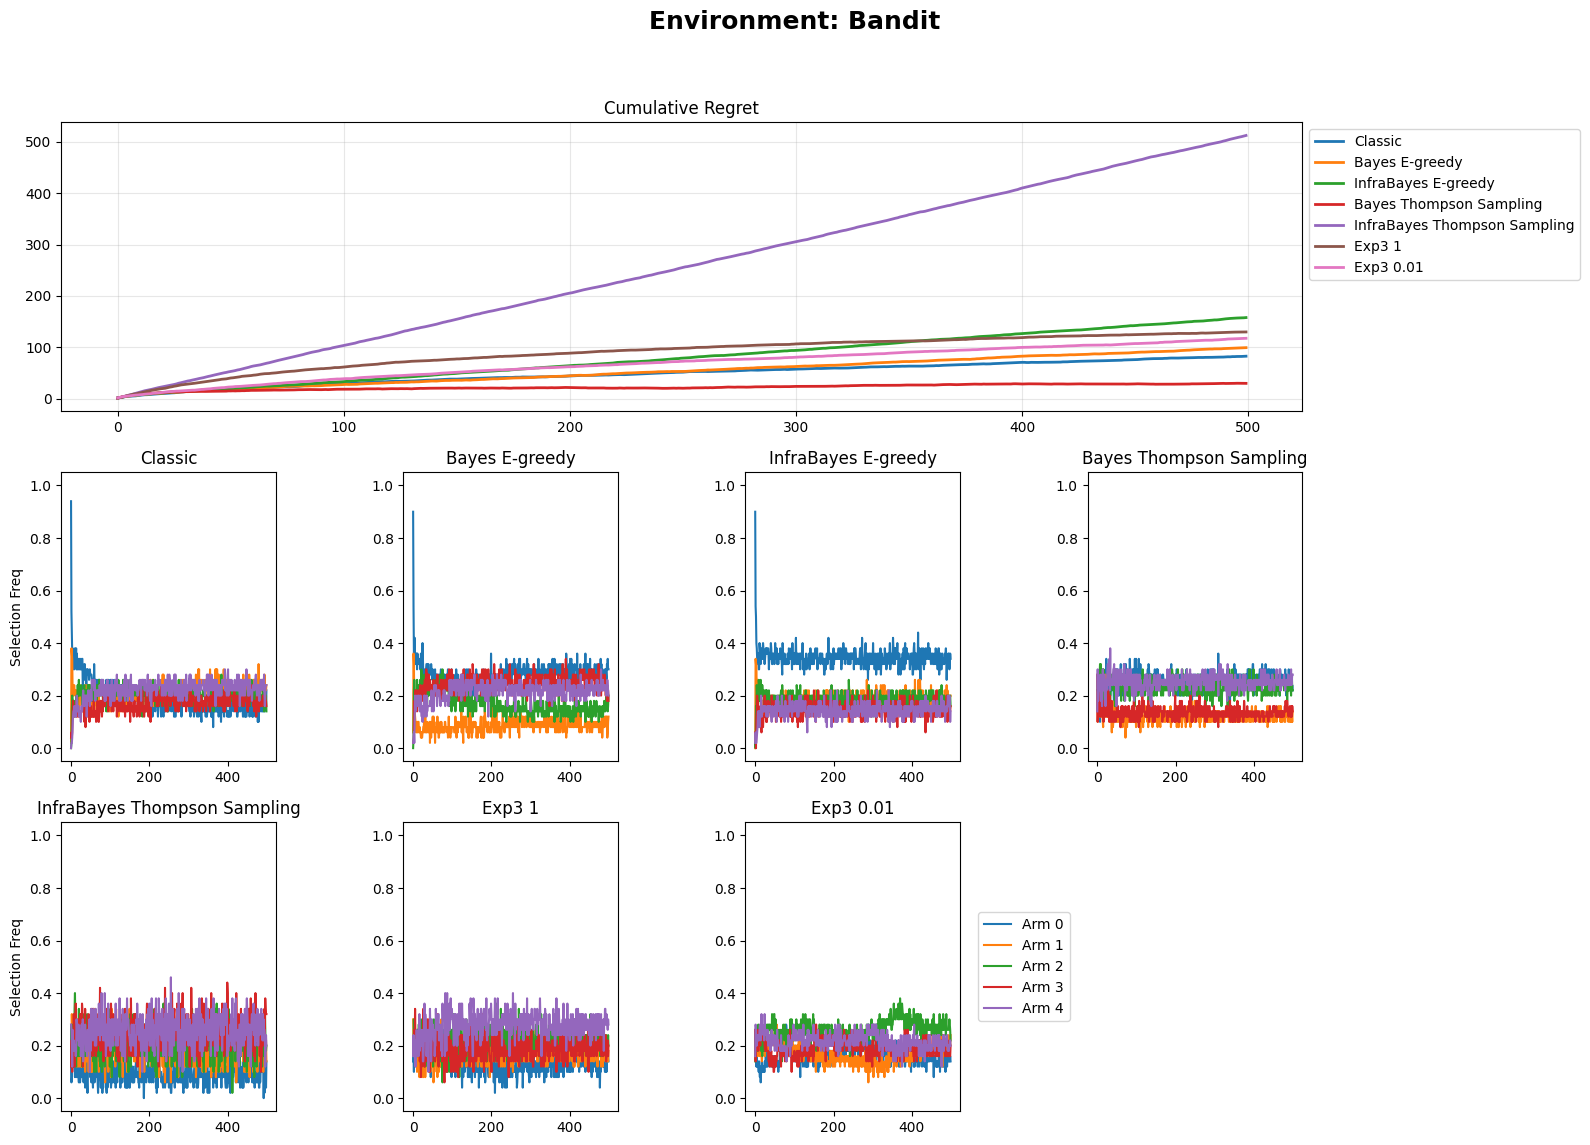

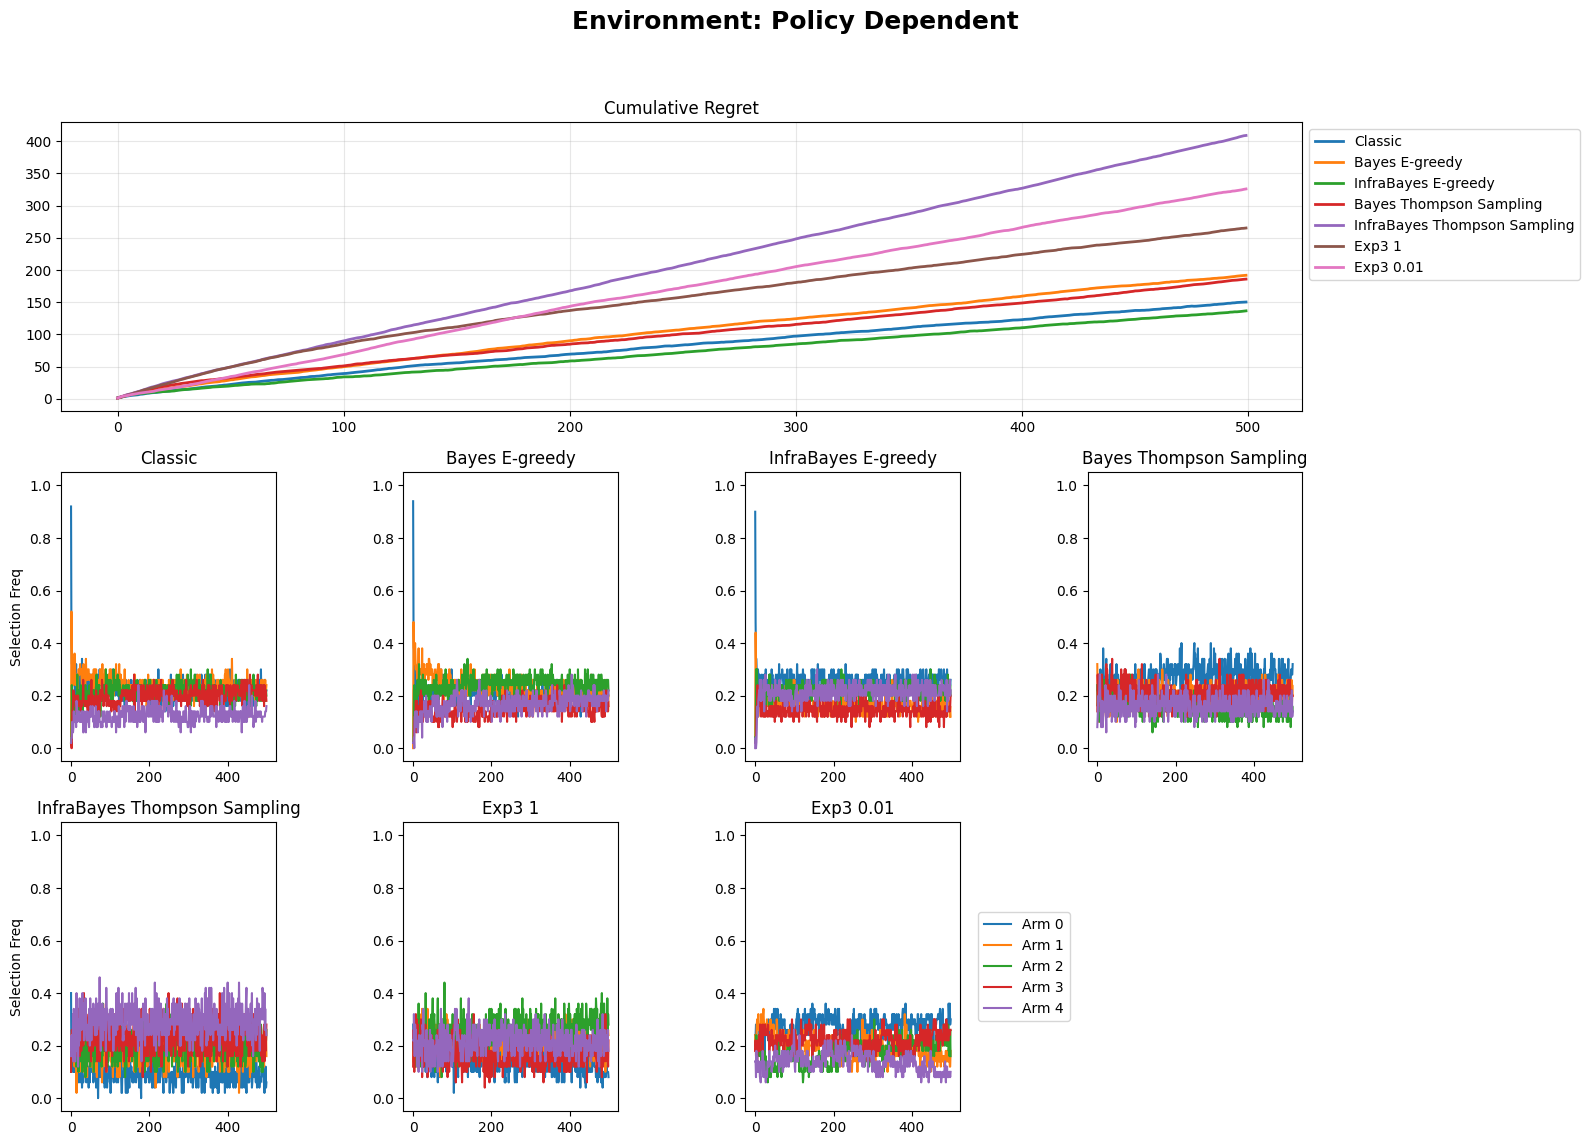

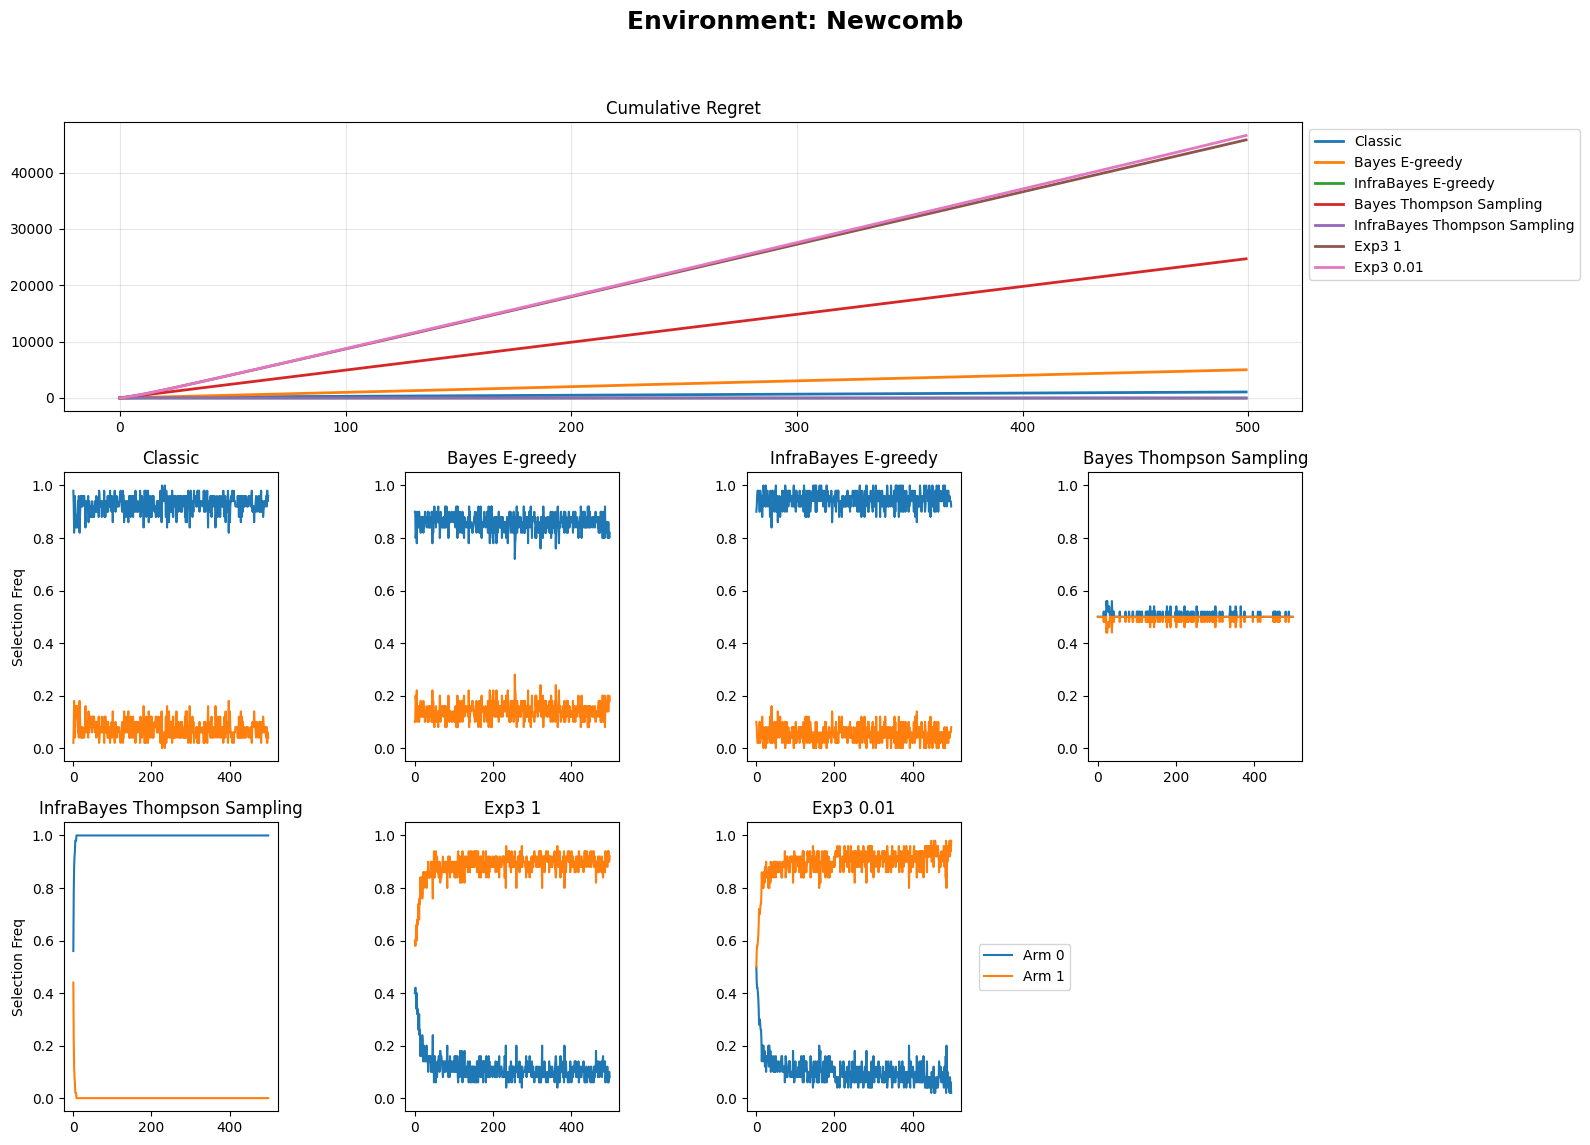

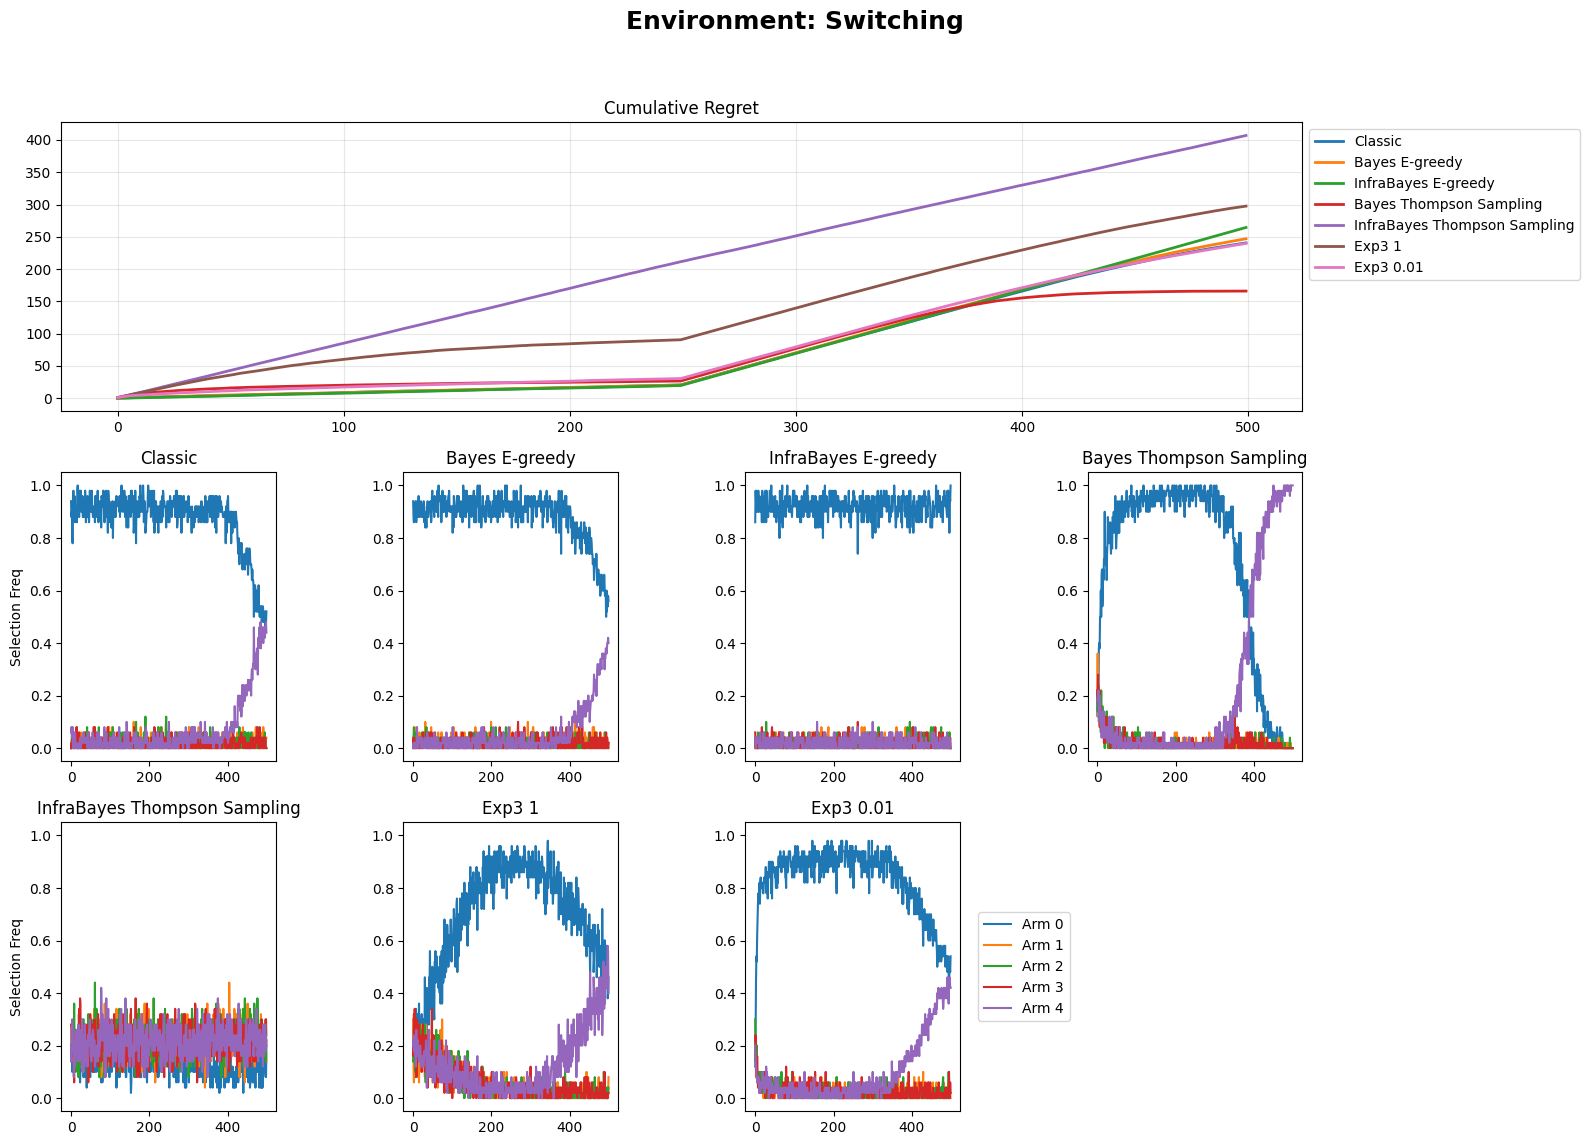

In [2]:
agent_targets = [
    ("Classic", ClassicalAgent, {}),
    ("Bayes E-greedy", BayesianAgent, {}),
    ("InfraBayes E-greedy", InfrabayesianAgent, {}),
    ("Bayes Thompson Sampling", BayesianThompsonAgent, {}),
    ("InfraBayes Thompson Sampling", InfrabayesianThompsonAgent, {}),
    ("Exp3 1", EXP3Agent, {"max_reward":1}),
    ("Exp3 0.01", EXP3Agent, {"max_reward":0.01}),
]

env_targets = [
    ("Bandit", BanditEnvironment, {"k":5}), 
    ("Policy Dependent", PolicyDependentBanditEnvironment, {"k":5}), 
    ("Newcomb", NewcombEnvironment, {"k":2}),
    ("Switching", SwitchingAdversaryEnvironment, {"k":5,"switch_at": 250}) 
]



cols = 4 # Set maximum columns for wrapping

for env_name, env_cls, env_kw in env_targets:
    results = {}
    # Detect k from the environment class or name
    k_val = 2 if "Newcomb" in env_name else 5 
    
    # 1. Run Simulations
    for ag_name, ag_cls, ag_kw in agent_targets:
        e_fact = lambda: env_cls(**env_kw)
        a_fact = lambda k: ag_cls(k=k, **ag_kw)
        regret, actions = simulate(e_fact, a_fact, steps=500, runs=50)
        results[ag_name] = (regret, actions)

    # 2. Calculate Layout
    num_agents = len(results)
    num_rows = math.ceil(num_agents / cols) + 1 # +1 for the regret row
    
    fig = plt.figure(figsize=(cols * 4, num_rows * 4))
    fig.suptitle(f"Environment: {env_name}", fontsize=18, fontweight='bold')

    # 3. Top Plot: Cumulative Regret (Spans first row)
    ax_regret = plt.subplot(num_rows, 1, 1)
    for name, (regret, _) in results.items():
        ax_regret.plot(regret, label=name, linewidth=2)
    ax_regret.set_title("Cumulative Regret")
    ax_regret.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax_regret.grid(True, alpha=0.3)

    # 4. Wrap Subplots: Action Frequencies
    for i, (name, (regret, actions)) in enumerate(results.items()):
        # index starts at cols + 1 to skip the first row
        ax_act = plt.subplot(num_rows, cols, i + cols + 1)
        for arm in range(k_val):
            freq = (actions == arm).mean(axis=0)
            ax_act.plot(freq, label=f"Arm {arm}")
        
        ax_act.set_title(f"{name}")
        ax_act.set_ylim(-0.05, 1.05)
        if i % cols == 0:
            ax_act.set_ylabel("Selection Freq")
        if i == num_agents - 1:
            ax_act.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()